# ZeroER++ — hyperparameter tuning (phase 1)

One Optuna study per dataset on the seeded ~30% partition; a Pareto problem over **(max F1, min surviving block pairs, max blocking recall)**, saved to `outputs/optuna.db`.

In [1]:
from pyjedai_module import ZeroEREstimator
from utils import (DATASETS, DEFAULT_TUNE_FRACTION, load_data,
                   precision_recall_f1, blocking_recall,   # objective helpers
                   tune_all, show_results, trial_budget)

/opt/conda/envs/chinochat/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/opt/conda/envs/chinochat/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-01 08:05:07,464	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Search space & budget

In [2]:
SEED = 0
SPACE = {                                     # the knobs; each key is a flat ZeroEREstimator arg
    # embeddings branch — PLM blocking. Static vectorizers (word2vec/glove/...) excluded: not LMs.
    "vectorizer": ["sminilm", "smpnet", "st5", "sdistilroberta",   # sentence-transformer PLMs
                   "bert", "distilbert", "roberta", "xlnet", "albert"],  # token PLMs
    "top_k": (1, 10),                         # neighbours kept per entity
    "similarity_distance": ["cosine", "euclidean"],
    # standard branch — syntactic blocking + cleaning
    "smoothing_factor": (1.0, 1.5),           # BlockPurging threshold
    "block_filtering_ratio": (0.5, 0.95),     # BlockFiltering keep-ratio
    "weighting_scheme": ["CBS", "ECBS", "JS", "EJS", "X2"],  # WeightedEdgePruning
    # matcher (searched in both branches)
    "c_bay": (1e-3, 3e-1),                    # ZeroER EM regularisation (log-float)
}
N_STARTUP_TRIALS = 12                          # TPE random warm-up before it models the space
N_TRIALS = trial_budget(SPACE, N_STARTUP_TRIALS)   # warm-up + ⅓ of the discrete grid = 73

## Objective

The per-experiment trial — declared here, not in `utils`, so a new experiment is just a copy-and-tweak of this cell. It returns `(F1, candset, pair_completeness)` and carries its own `directions`; `make_objective` binds it to `SPACE`/`SEED` for the runners.

In [3]:
class TuningObjective:
    """Multi-objective trial: (max F1, min surviving block pairs, max pair completeness).

    One ``Data`` is loaded per instance and reused across trials; ``get_params``
    *is* the search space (keys map one-to-one onto the ZeroEREstimator ctor).
    """
    directions = ["maximize", "minimize", "maximize"]   # F1 up, block pairs down, PC up

    def __init__(self, dataset, space, seed=0, partition=True):
        self.space = space
        self.source_trial = None              # set by retrain_full to stamp each full trial
        self.data = load_data(dataset, partition=partition, seed=seed)
        self.attributes = DATASETS[dataset]["attributes"]
        frac = DATASETS[dataset].get("tune_fraction", DEFAULT_TUNE_FRACTION)
        scope = f"partition (frac={frac})" if partition else "full data"
        print(f"    {scope}: {self.data.num_of_entities_1}+{self.data.num_of_entities_2}"
              f" entities, {len(self.data.ground_truth)} matches", flush=True)

    def get_params(self, trial):
        # conditional: the blocker is itself a knob; each branch exposes only its
        # own stage params; c_bay (the matcher) is searched in both branches.
        s = self.space
        blocker = trial.suggest_categorical("blocker", ["embeddings", "standard"])
        params = dict(blocker=blocker,
                      c_bay=trial.suggest_float("c_bay", *s["c_bay"], log=True))
        if blocker == "embeddings":
            params.update(
                vectorizer=trial.suggest_categorical("vectorizer", s["vectorizer"]),
                top_k=trial.suggest_int("top_k", *s["top_k"]),
                similarity_distance=trial.suggest_categorical("similarity_distance", s["similarity_distance"]),
            )
        else:
            params.update(
                smoothing_factor=trial.suggest_float("smoothing_factor", *s["smoothing_factor"]),
                block_filtering_ratio=trial.suggest_float("block_filtering_ratio", *s["block_filtering_ratio"]),
                weighting_scheme=trial.suggest_categorical("weighting_scheme", s["weighting_scheme"]),
            )
        return params

    def __call__(self, trial):
        est = ZeroEREstimator(attributes=self.attributes, **self.get_params(trial))
        graph = est.fit_predict(self.data)
        _, _, f1 = precision_recall_f1(graph, self.data)
        pair_completeness = blocking_recall(est.blocks, self.data)   # gold kept by the blocker
        trial.set_user_attr("candset_size", est.candset_size)
        trial.set_user_attr("blocking_seconds", round(est.blocking_seconds, 3))
        trial.set_user_attr("em_seconds", round(est.matcher.em_time, 3))
        if self.source_trial is not None:
            trial.set_user_attr("source_trial", self.source_trial)
        return f1, est.candset_size, pair_completeness


def make_objective(dataset, partition=True):                 # factory the runners call per dataset
    return TuningObjective(dataset, SPACE, SEED, partition=partition)

## Run phase 1 — tune on the partition

Resumable: re-running continues the existing studies.

In [4]:
tune_all(make_objective, n_trials=N_TRIALS, n_startup_trials=N_STARTUP_TRIALS, seed=SEED)


=== tuning fodors_zagats (73 trials) ===
    partition (frac=0.3): 160+100 entities, 34 matches


/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-06-01 08:05:13,212] A new study created in RDB with name: fodors_zagats
/opt/conda/envs/chinochat/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
  0%|          | 0/40 [00:00<?, ?it/s]/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:440: RuntimeWarning: 

  pareto: F1=0.8684 candset=46 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.11395032674446523, 'smoothing_factor': 1.0305874260352816, 'block_filtering_ratio': 0.8289005337914328, 'weighting_scheme': 'CBS'}
  pareto: F1=0.5532 candset=43 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.07828505974835948, 'smoothing_factor': 1.0225622435990447, 'block_filtering_ratio': 0.7807665605599864, 'weighting_scheme': 'CBS'}
  pareto: F1=0.9706 candset=48 PC=0.9706 {'blocker': 'standard', 'c_bay': 0.06960177067322433, 'smoothing_factor': 1.002074934101734, 'block_filtering_ratio': 0.7944271064048356, 'weighting_scheme': 'EJS'}
  pareto: F1=0.4186 candset=41 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.06175906143017537, 'smoothing_factor': 1.0337032370132886, 'block_filtering_ratio': 0.7221472631514566, 'weighting_scheme': 'ECBS'}
  pareto: F1=0.9552 candset=49 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.09437940898537311, 'smoothing_factor': 1.016858724839636, 'block_filtering_ratio': 0.81828274075

/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-06-01 08:07:53,627] A new study created in RDB with name: dblp_acm
 45%|████▌     | 18/40 [00:00<00:00, 92.69it/s]
[I 2026-06-01 08:07:57,128] Trial 0 finished with values: [0.9290322580645161, 10122.0, 1.0] and parameters: {'blocker': 'standard', 'c_bay': 0.0311256170909018, 'smoothing_factor': 1.2724415914984484, 'block_filtering_ratio': 0.6906446597025071, 'weighting_scheme': 'EJS'}.
 35%|███▌      | 14/40 [00:00<00:00, 257.71it/s]
[I 2026-06-01 08:08:00,193] Trial 1 finished with values: [0.6886517943743938, 3440.0, 0.5352323838080959] and

  pareto: F1=0.9837 candset=1376 PC=1.0000 {'blocker': 'embeddings', 'c_bay': 0.007867226146268723, 'vectorizer': 'st5', 'top_k': 2, 'similarity_distance': 'cosine'}
  pareto: F1=0.9940 candset=688 PC=0.9955 {'blocker': 'embeddings', 'c_bay': 0.0055113428604880825, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'cosine'}

=== tuning dblp_scholar (73 trials) ===
    partition (frac=0.3): 1242+19309 entities, 1639 matches


...

  pareto: F1=0.0409 candset=212926 PC=0.9994 {'blocker': 'standard', 'c_bay': 0.0010324380974467869, 'smoothing_factor': 1.2783363780105759, 'block_filtering_ratio': 0.5415641500548766, 'weighting_scheme': 'X2'}
  pareto: F1=0.4425 candset=19309 PC=0.9549 {'blocker': 'embeddings', 'c_bay': 0.004342708044636484, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'cosine'}
  pareto: F1=0.8219 candset=114628 PC=0.9988 {'blocker': 'standard', 'c_bay': 0.01217640874215835, 'smoothing_factor': 1.4835133227364306, 'block_filtering_ratio': 0.6422214437859184, 'weighting_scheme': 'CBS'}
  pareto: F1=0.8213 candset=92544 PC=0.9988 {'blocker': 'standard', 'c_bay': 0.012922242412813024, 'smoothing_factor': 1.2719344697766684, 'block_filtering_ratio': 0.6200753933719224, 'weighting_scheme': 'CBS'}
  pareto: F1=0.8191 candset=54353 PC=0.9982 {'blocker': 'standard', 'c_bay': 0.01708784851475899, 'smoothing_factor': 1.2208666089361322, 'block_filtering_ratio': 0.573282932972805, 'weighting_scheme

/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-06-01 09:19:09,930] A new study created in RDB with name: abt_buy
  0%|          | 0/40 [00:00<?, ?it/s]/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:440: RuntimeWarning: some failed to converge after 5 iterations
  kappas = newton(bay_coeff_equ, x0=x0, x1=x1, maxiter=5, tol=1)
 30%|███       | 12/40 [00:00<00:00, 344.98it/s]
[I 2026-06-01 09:19:12,835] Trial 0 finished with values: [0.14461538461538462, 3264.0, 0.9635258358662614] and parameters: {'blocker': 'standard', 'c_bay': 0.0311256170909018, 'smoothing_factor': 1.27

  pareto: F1=0.0712 candset=8524 PC=0.9970 {'blocker': 'standard', 'c_bay': 0.0017088424969157376, 'smoothing_factor': 1.2879732477780896, 'block_filtering_ratio': 0.9181832889092962, 'weighting_scheme': 'EJS'}
  pareto: F1=0.1834 candset=2303 PC=0.9878 {'blocker': 'embeddings', 'c_bay': 0.003293446296327548, 'vectorizer': 'st5', 'top_k': 7, 'similarity_distance': 'cosine'}
  pareto: F1=0.3832 candset=329 PC=0.8419 {'blocker': 'embeddings', 'c_bay': 0.0023563821709718705, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'euclidean'}
  pareto: F1=0.3832 candset=329 PC=0.8419 {'blocker': 'embeddings', 'c_bay': 0.0016040106934220829, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'euclidean'}
  pareto: F1=0.3467 candset=658 PC=0.9210 {'blocker': 'embeddings', 'c_bay': 0.002362837633219082, 'vectorizer': 'st5', 'top_k': 2, 'similarity_distance': 'euclidean'}
  pareto: F1=0.3040 candset=987 PC=0.9635 {'blocker': 'embeddings', 'c_bay': 0.0010573734835665717, 'vectorizer': 'st

/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/utils.py:272: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-06-01 09:25:34,777] A new study created in RDB with name: amazon_googleproducts
 42%|████▎     | 17/40 [00:00<00:01, 22.97it/s]
[I 2026-06-01 09:26:02,347] Trial 0 finished with values: [0.17816901408450705, 51746.0, 0.9461538461538461] and parameters: {'blocker': 'standard', 'c_bay': 0.0311256170909018, 'smoothing_factor': 1.2724415914984484, 'block_filtering_ratio': 0.6906446597025071, 'weighting_scheme': 'EJS'}.
 50%|█████     | 20/40 [00:00<00:00, 181.74it/s]
[I 2026-06-01 09:27:45,227] Trial 1 finished with values: [0.09037328094302553, 4

ValueError: Found array with 1 sample(s) (shape=(1, 1)) while a minimum of 2 is required by GaussianMixture.

## Results

Pareto-optimal configs (best F1 first) + the fronts in the two F1 trade-off planes. Only `partition` fronts exist until `zeroer.ipynb` retrains the `full` ones.

In [5]:
try:
    from IPython.display import display
except ImportError:
    display = print

=== partition: 55 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,blocker,vectorizer,top_k,similarity_distance,smoothing_factor,block_filtering_ratio,weighting_scheme,c_bay,blocking_seconds,em_seconds,source_trial
0,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00236,0.009,0.064,None
1,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00160,0.009,0.065,None
2,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,cosine,NaN,NaN,None,0.00163,0.010,0.064,None
3,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00236,0.011,0.064,None
4,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00255,0.009,0.064,None
5,abt_buy,partition,0.3467,658,0.9210,embeddings,st5,2.0,euclidean,NaN,NaN,None,0.00236,0.009,0.068,None
6,abt_buy,partition,0.3467,658,0.9210,embeddings,st5,2.0,euclidean,NaN,NaN,None,0.00143,0.009,0.069,None
7,abt_buy,partition,0.3040,987,0.9635,embeddings,st5,3.0,euclidean,NaN,NaN,None,0.00106,0.009,0.072,None
8,abt_buy,partition,0.3040,987,0.9635,embeddings,st5,3.0,euclidean,NaN,NaN,None,0.00102,0.010,0.071,None
9,abt_buy,partition,0.2606,1316,0.9696,embeddings,st5,4.0,cosine,NaN,NaN,None,0.00104,0.010,0.077,None


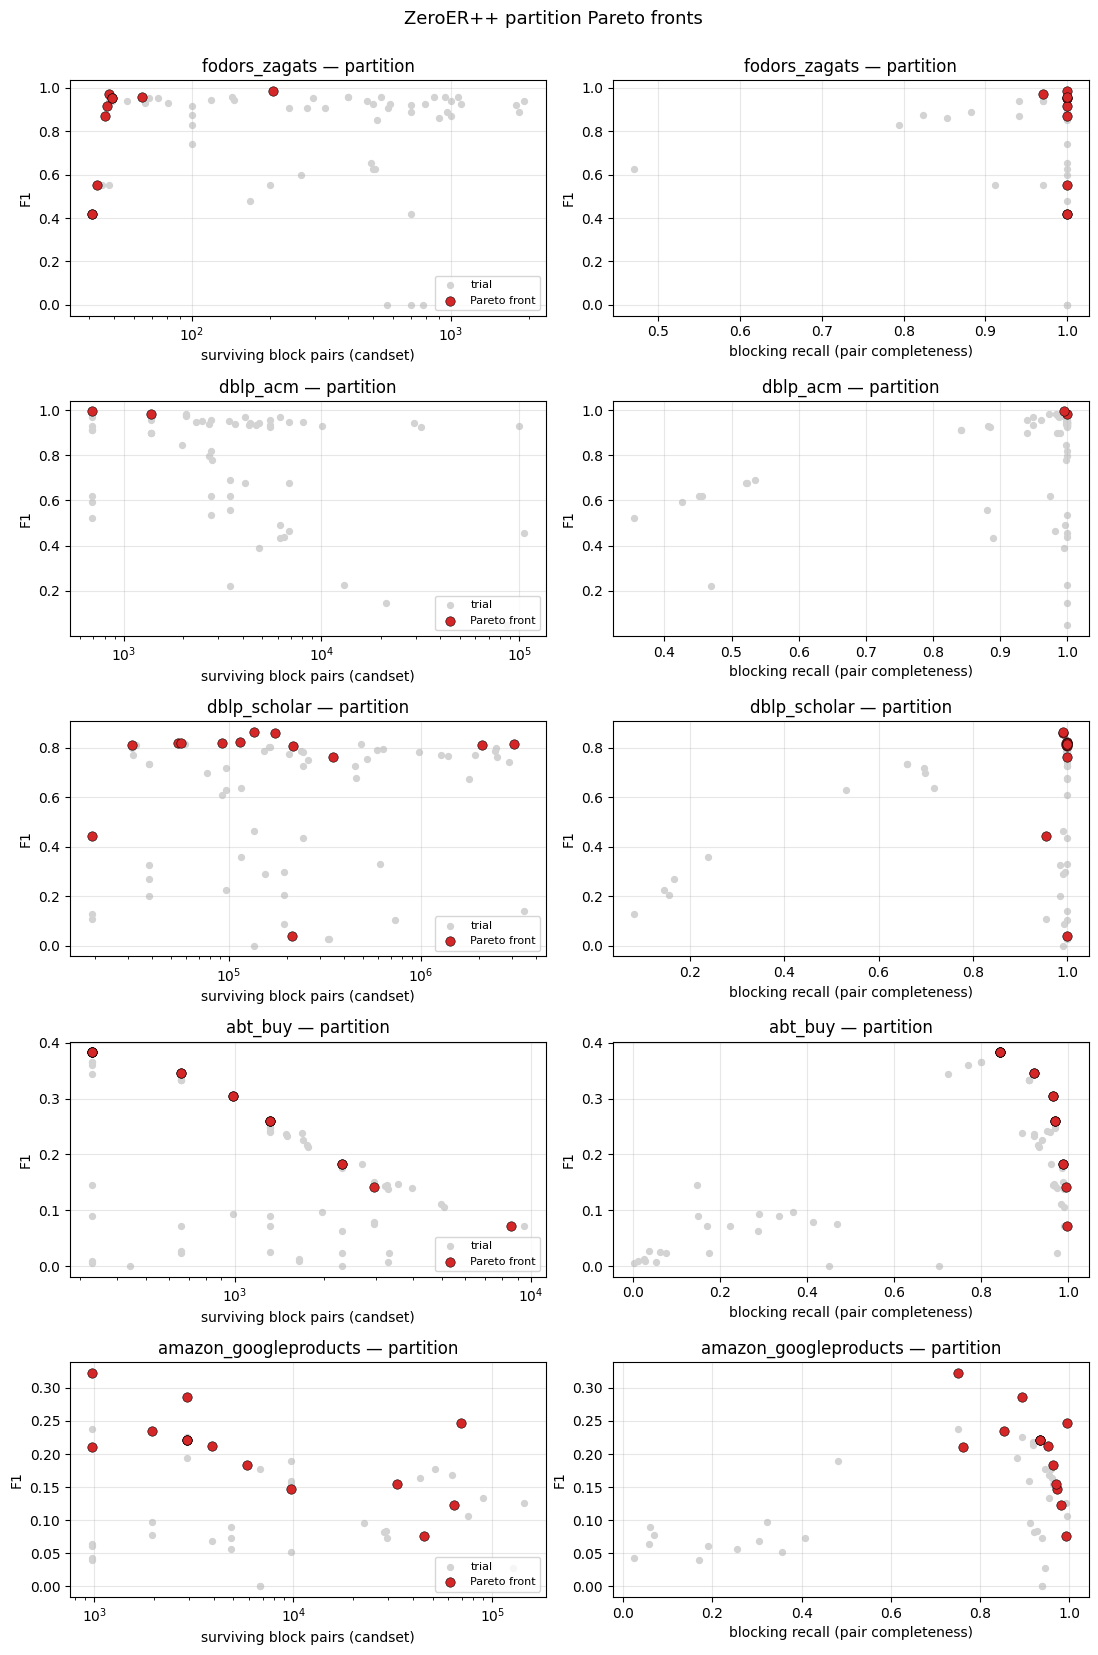

In [6]:
show_results()